# 02 — OLS Baseline & Granger Causality

**Objective:** Establish linear benchmark and validate causal feature selection.

Sections:
1. OLS fit per country (R², CV stability)
2. VIF analysis — identify multicollinearity issues
3. Residual breakdown (low/mid/high price regions)
4. Granger causality tests

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import statsmodels.api as sm
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')
from src.models.baseline import (
    fit_ols, run_stability, get_vif, get_statsmodels_summary,
    run_all_countries, SAFE_FEATURES, TARGET
)
sns.set_theme(style='whitegrid')
OUT_DIR = 'reports/figures/01_ols_baseline'
os.makedirs(OUT_DIR, exist_ok=True)
print('Ready.')

Ready.


In [2]:
df = pd.read_csv('data/processed/electricity_dataset.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df = df.sort_values(['Country','Datetime']).reset_index(drop=True)
print(f'{len(df):,} rows')

420,768 rows


## 1. OLS Summary — All Countries

In [3]:
summary = run_all_countries(df)
summary

  [DE] OLS hoàn tất: R2=0.848 | CV=-0.001 ± 1.402


  [DK] OLS hoàn tất: R2=0.745 | CV=0.050 ± 0.780
  [ES] OLS hoàn tất: R2=0.716 | CV=-0.470 ± 1.526


  [FR] OLS hoàn tất: R2=0.853 | CV=0.292 ± 0.684


  [IT] OLS hoàn tất: R2=0.912 | CV=0.267 ± 0.674
  [PL] OLS hoàn tất: R2=0.689 | CV=0.330 ± 0.081


,Country,R2_full,CV_mean_R2,CV_std_R2,N
0,DE,0.8483,-0.0006,1.4016,70128
1,DK,0.7450,0.0505,0.7796,70128
2,ES,0.7161,-0.4698,1.5262,70128
3,FR,0.8525,0.2919,0.6837,70128
4,IT,0.9124,0.2671,0.6737,70128
5,PL,0.6892,0.3297,0.0811,70128


## 2. VIF Analysis (Multicollinearity)

In [4]:
country = 'DE'  # Change to inspect other countries
df_c = df[df['Country'] == country]
avail = [f for f in SAFE_FEATURES if f in df_c.columns]
vif_table = get_vif(df_c, avail)
print(f'VIF Table for {country}:')
vif_table

VIF Table for DE:


,Feature,VIF
0,Load,inf
1,Residual_Load,inf
2,Wind_Onshore_MW,inf
3,Wind_Offshore_MW,inf
4,Hydro_RoR_MW,inf
5,Solar_MW,inf
6,Coal_Price,9.73
7,TTF_Gas_Price,6.54
8,Net_Import,4.16
9,Brent_Oil_Price,3.81


In [5]:
# Residual_Load has VIF=inf (linear combo of components) -> excluded from OLS
# This is a mathematical OLS issue, NOT relevant for HDBSCAN
ols_features = [f for f in avail if f != 'Residual_Load']
sm_result = get_statsmodels_summary(df_c, ols_features)
print(sm_result.summary())

                               OLS Regression Results                               
Dep. Variable:     Real_Wholesale_Price_EUR   R-squared:                       0.848
Model:                                  OLS   Adj. R-squared:                  0.848
Method:                       Least Squares   F-statistic:                 2.306e+04
Date:                      Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                              22:05:40   Log-Likelihood:            -3.3724e+05
No. Observations:                     70128   AIC:                         6.745e+05
Df Residuals:                         70110   BIC:                         6.747e+05
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

## 3. Residual Breakdown by Price Region

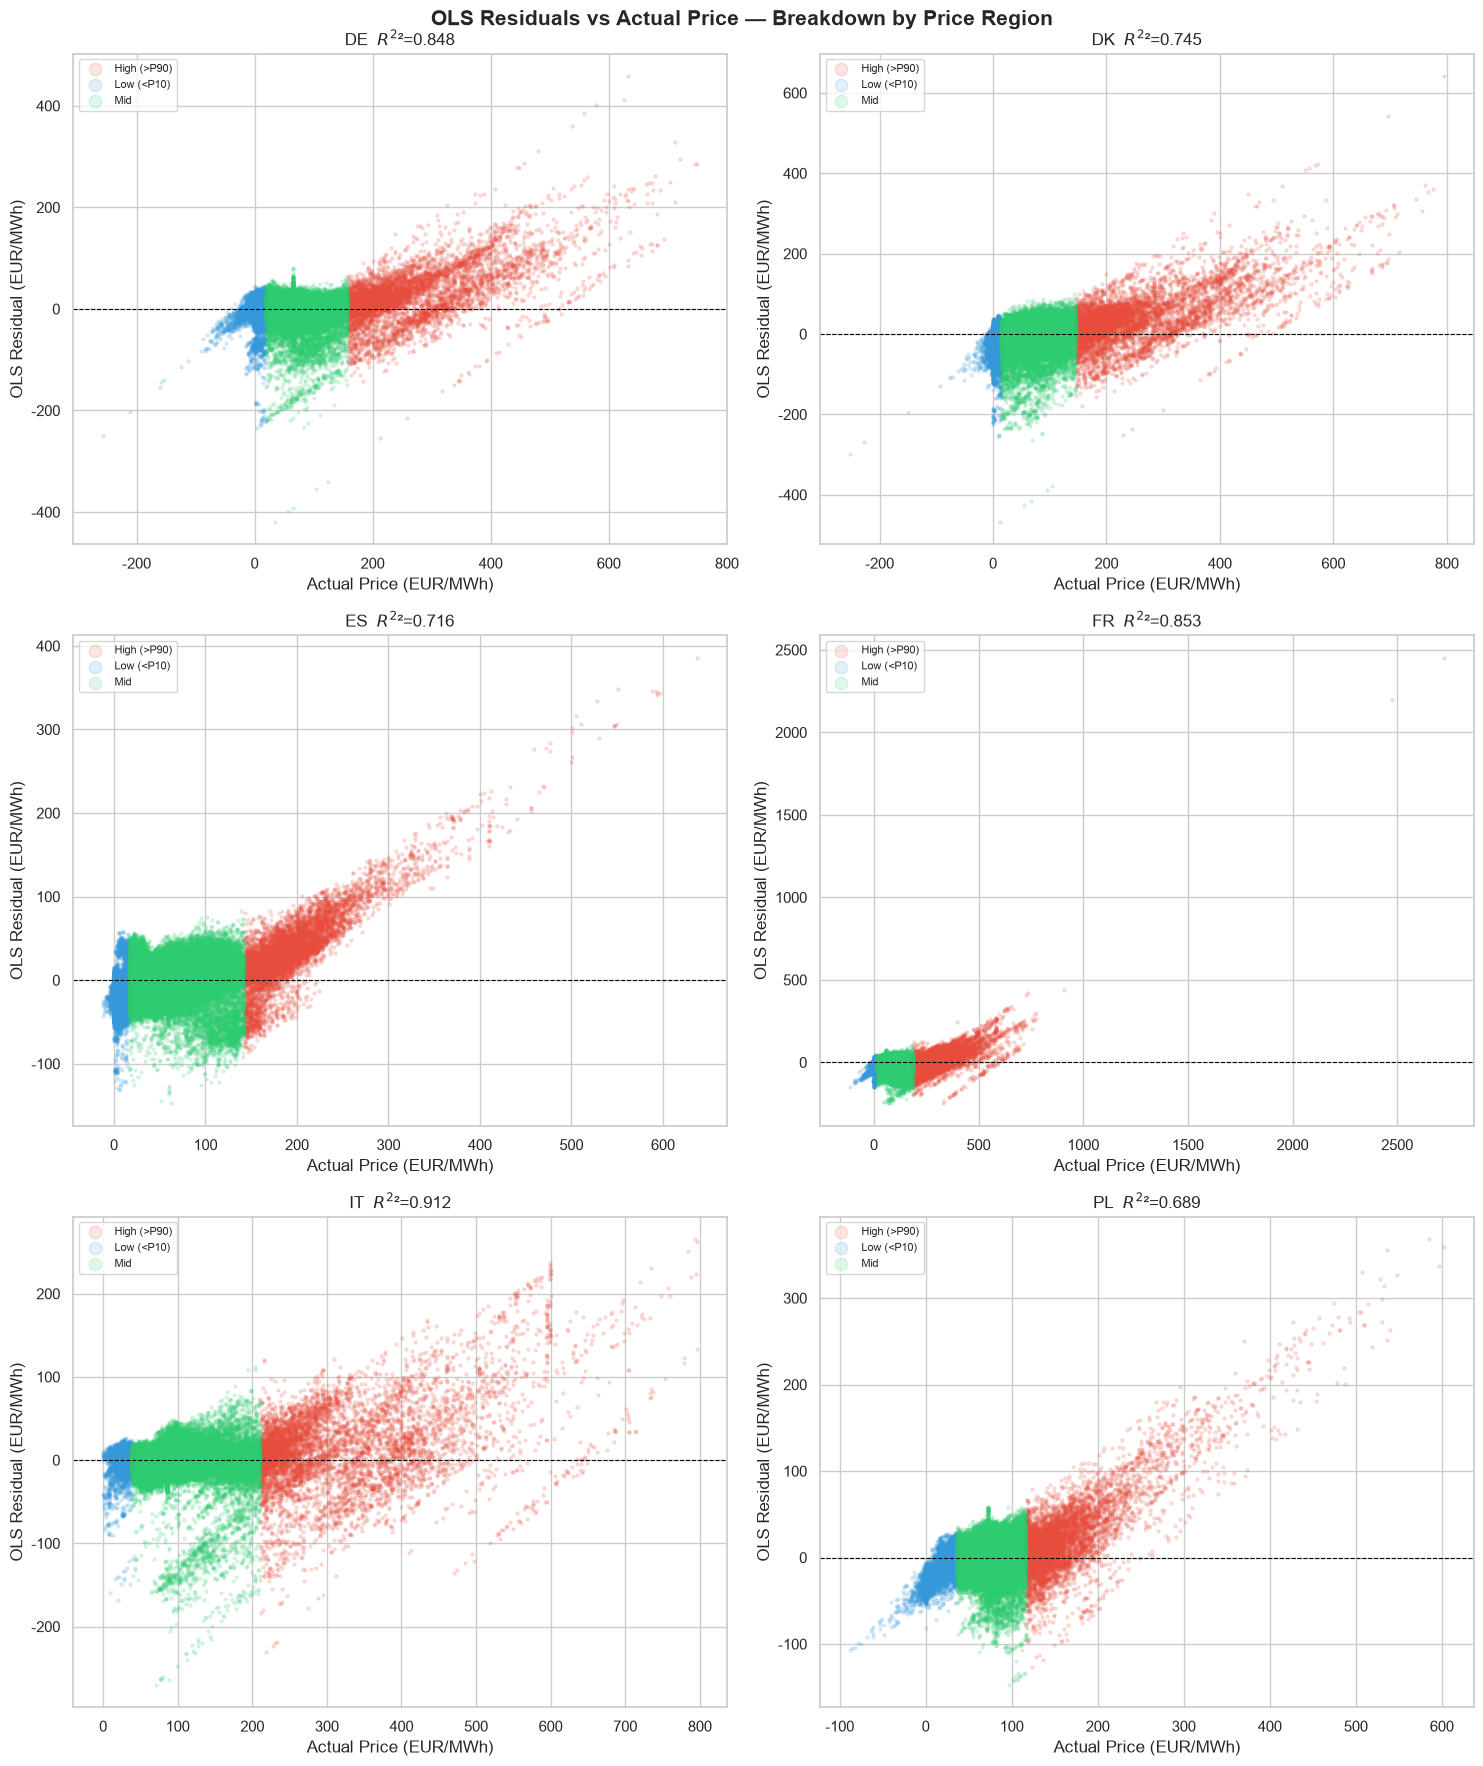

In [6]:
COUNTRIES = ['DE', 'DK', 'ES', 'FR', 'IT', 'PL']
fig, axes = plt.subplots(3, 2, figsize=(15, 18), sharey=False)
axes = axes.flatten()

for idx, country in enumerate(COUNTRIES):
    df_c = df[df['Country'] == country].copy()
    avail = [f for f in SAFE_FEATURES if f in df_c.columns and f != 'Residual_Load']
    model, residuals, r2 = fit_ols(df_c, avail)
    df_c['Residual'] = residuals.values

    p10 = df_c[TARGET].quantile(0.10)
    p90 = df_c[TARGET].quantile(0.90)
    def cat(p):
        if p < p10: return 'Low (<P10)'
        elif p > p90: return 'High (>P90)'
        else: return 'Mid'
    df_c['PriceRegion'] = df_c[TARGET].apply(cat)

    palette = {'Low (<P10)':'#3498db','Mid':'#2ecc71','High (>P90)':'#e74c3c'}
    ax = axes[idx]
    for region, grp in df_c.groupby('PriceRegion'):
        ax.scatter(grp[TARGET], grp['Residual'],
                   alpha=0.15, s=5, label=region, color=palette[region])
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'{country}  $R^2$²={r2:.3f}', fontsize=12)
    ax.set_xlabel('Actual Price (EUR/MWh)')
    ax.set_ylabel('OLS Residual (EUR/MWh)')
    ax.legend(markerscale=4, fontsize=8)

plt.suptitle('OLS Residuals vs Actual Price — Breakdown by Price Region', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'residuals_breakdown.png'), dpi=500, bbox_inches='tight')
plt.show()

## 4. Granger Causality Tests

In [7]:
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

def run_granger(df_c, cause, effect, maxlag=24):
    """un Granger test: does `cause` Granger-cause `effect`?"""
    data = df_c[[effect, cause]].dropna()
    res  = grangercausalitytests(data, maxlag=maxlag, verbose=False)
    pvals = [round(res[lag][0]['ssr_ftest'][1], 4) for lag in res]
    min_p = min(pvals)
    best_lag = pvals.index(min_p) + 1
    return {'cause': cause, 'effect': effect, 'min_p': min_p, 'best_lag': best_lag,
            'significant': min_p < 0.05}

country = 'DE'
df_c = df[df['Country'] == country].copy()
pairs = [
    ('TTF_Gas_Price',          TARGET),
    ('Residual_Load',          TARGET),
    ('EU_Gas_Storage_Anomaly', TARGET),
    ('Coal_Price',             TARGET),
]
results_g = [run_granger(df_c, c, e) for c, e in pairs]
pd.DataFrame(results_g)

,cause,effect,min_p,best_lag,significant
0,TTF_Gas_Price,Real_Wholesale_Price_EUR,0.0,1,True
1,Residual_Load,Real_Wholesale_Price_EUR,0.0,1,True
2,EU_Gas_Storage_Anomaly,Real_Wholesale_Price_EUR,0.0,1,True
3,Coal_Price,Real_Wholesale_Price_EUR,0.0,1,True


In [8]:
import shutil
import os
OUT_METH = "paper/figures/methodology"
os.makedirs(OUT_METH, exist_ok=True)

# Copy to methodology
shutil.copy(os.path.join(OUT_DIR, 'residuals_breakdown.png'), os.path.join(OUT_METH, 'residuals_breakdown.png'))
print("Plots integrated into Notebook 02!")

Plots integrated into Notebook 02!
